# 04 - Entrenar, evaluar y reportar XGBoost

En esta libreta dejo todo el pipeline final para LPMC, con dos opciones de hiperpar?metros: los de Jose Angel (fichero `lpmc_xgb_best_params.json`) o los m?os (`lpmc_xgb_custom_params.json`). Entreno el modelo completo, eval?o en test, calculo m?tricas 5-CV por hogar (como en el paper) y guardo artefactos. Uso siempre `RANDOM_STATE = 481516`.


## 1. Imports y configuración

Cargo librerías, rutas y la lista de columnas que escalo. Fijo el random_state a 481516 para que todo sea reproducible.

In [78]:
from pathlib import Path
import json
import os
import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from collections import Counter, defaultdict


In [79]:
ROOT = Path.cwd()
DATA_DIR = ROOT / 'data' / 'preprocessed'
ARTIFACTS = ROOT / 'artifacts'
MODELS = ROOT / 'models'
MODELS.mkdir(exist_ok=True)

DEFAULT_SCALED_FEATURES = [
    'day_of_week', 'start_time_linear', 'age', 'car_ownership',
    'distance', 'dur_walking', 'dur_cycling', 'dur_pt_access', 'dur_pt_rail',
    'dur_pt_bus', 'dur_pt_int_waiting', 'dur_pt_int_walking', 'pt_n_interchanges',
    'dur_driving', 'cost_transit', 'cost_driving_total',
]

RANDOM_STATE = 481516


## 2. Elegir hiperparámetros (Jose Angel o míos)

Aquí decido qué conjunto de hiperparámetros usar: los de Jose Angel (PARAM_SOURCE = 'profe') o los que obtuve en mi propia búsqueda ('custom'). Leo el JSON correspondiente de artifacts, aviso si no existe el custom y muestro por pantalla los valores activos. Así puedo cambiar de configuración sin tocar más celdas.

In [80]:
PARAM_SOURCE = 'custom'  # 'profe' o 'custom'

PROF_PATH = ARTIFACTS / 'lpmc_xgb_best_params.json'
CUSTOM_PATH = ARTIFACTS / 'lpmc_xgb_custom_params.json'

def load_params(source: str):
    if source == 'custom' and CUSTOM_PATH.exists():
        bundle = json.loads(CUSTOM_PATH.read_text())
        print('Usando hiperpar?metros CUSTOM de', CUSTOM_PATH)
        return bundle
    bundle = json.loads(PROF_PATH.read_text())
    if source == 'custom':
        print('No se encontr? custom; uso los de Jose Angel')
    else:
        print('Usando hiperpar?metros de Jose Angel de', PROF_PATH)
    return bundle

bundle = load_params(PARAM_SOURCE)
model_params = bundle['params']
scaled_features = bundle.get('scaled_features', DEFAULT_SCALED_FEATURES)
print('Par?metros activos:')
for k, v in model_params.items():
    print(f"  {k}: {v}")


Usando hiperpar?metros CUSTOM de f:\TFM\lpmc\artifacts\lpmc_xgb_custom_params.json
Par?metros activos:
  colsample_bytree: 0.9911780478619544
  gamma: 2.499996019648383
  learning_rate: 0.09258949217113338
  max_depth: 6
  min_child_weight: 17
  n_estimators: 900
  reg_alpha: 0.6836695859198154
  reg_lambda: 0.053597416554023405
  subsample: 0.6206611465973016
  objective: multi:softprob
  eval_metric: mlogloss
  num_class: 4
  n_jobs: -1
  random_state: 481516


## 3. Cargar datos y alinear columnas

Leo los CSV preprocesados (`LPMC_train.csv` y `LPMC_test.csv`), separo features y target, y alineo columnas entre train y test: añado con 0 las columnas que faltan en cada uno y reordeno para que coincidan. Esto evita errores de forma al entrenar y predecir.

In [81]:
target_col = 'travel_mode'
train = pd.read_csv(DATA_DIR / 'LPMC_train.csv')
test = pd.read_csv(DATA_DIR / 'LPMC_test.csv')

X_train = train.drop(columns=[target_col])
y_train = train[target_col].astype(int)
X_test = test.drop(columns=[target_col])
y_test = test[target_col].astype(int)

missing_in_test = set(X_train.columns) - set(X_test.columns)
for c in missing_in_test:
    X_test[c] = 0
missing_in_train = set(X_test.columns) - set(X_train.columns)
for c in missing_in_train:
    X_train[c] = 0
X_test = X_test[X_train.columns]


## 4. Escalado de variables numéricas

Aplico StandardScaler solo a las columnas numéricas que definimos (las mismas que en el paper). Creo copias de X_train y X_test y sustituyo esas columnas por sus versiones escaladas. Así el modelo ve las variables en la misma escala que usó Jose Angel.

In [82]:
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[scaled_features] = scaler.fit_transform(X_train[scaled_features].astype(float))
X_test_scaled[scaled_features] = scaler.transform(X_test[scaled_features].astype(float))


## 5. Entrenamiento completo y m?tricas hold-out

Entreno el XGBClassifier con los hiperparámetros elegidos. Si la variable de entorno FAST_N_ESTIMATORS está definida, reduzco n_estimators para pruebas rápidas. Tras entrenar, calculo predicciones y probabilidades en train y test, y obtengo Accuracy y GMPCA (definida como exp(log_like medio), con clipping numérico). Muestro las métricas de train y test como referencia inmediata.

In [83]:
fast_override = os.environ.get('FAST_N_ESTIMATORS')
if fast_override:
    model_params = dict(model_params)
    model_params['n_estimators'] = int(fast_override)
    print('FAST_N_ESTIMATORS activo -> n_estimators', model_params['n_estimators'])

clf = XGBClassifier(**model_params)
print('Entrenando XGBoost...')
clf.fit(X_train_scaled, y_train)

proba_train = clf.predict_proba(X_train_scaled)
proba_test = clf.predict_proba(X_test_scaled)
y_pred_train = clf.predict(X_train_scaled)
y_pred_test = clf.predict(X_test_scaled)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

def gmpca_from_proba(proba, y_true):
    proba = np.asarray(proba)
    y_true = np.asarray(y_true)
    proba = np.clip(proba, 1e-12, 1.0)
    log_like = np.log(proba[np.arange(len(y_true)), y_true]).sum()
    return float(np.exp(log_like / len(y_true)))

gmpca_train = gmpca_from_proba(proba_train, y_train)
gmpca_test = gmpca_from_proba(proba_test, y_test)

print(f'Accuracy train: {acc_train:.4f} ({acc_train*100:.2f}%)')
print(f'Accuracy test : {acc_test:.4f} ({acc_test*100:.2f}%)')
print(f'GMPCA train   : {gmpca_train:.4f} ({gmpca_train*100:.2f}%)')
print(f'GMPCA test    : {gmpca_test:.4f} ({gmpca_test*100:.2f}%)')


Entrenando XGBoost...
Accuracy train: 0.8009 (80.09%)
Accuracy test : 0.7425 (74.25%)
GMPCA train   : 0.5971 (59.71%)
GMPCA test    : 0.5101 (51.01%)


## 6. Cross-Validation 5-CV por hogar (estilo Jose Angel)

Para replicar las tablas del paper, hago una CV de 5 folds estratificada por household_id (misma función que en el repo del tutor). En cada fold reentreno un modelo desde cero, escalo dentro del fold y calculo Accuracy y GMPCA. Imprimo los resultados por fold y la media ± desviación estándar. Si pongo RUN_CV = False, me salto esta parte para ahorrar tiempo.

In [84]:
RUN_CV = True 
CV_FOLDS = 5
GROUP_COL = 'household_id'

# Stratified Group K-Fold adaptado del repo de Jose Angel
def stratified_group_k_fold(X, y, groups, k, seed=None):
    labels_num = int(np.max(y)) + 1
    y_counts_per_group = defaultdict(lambda: np.zeros(labels_num))
    y_distr = Counter()
    for label, g in zip(y, groups):
        y_counts_per_group[g][label] += 1
        y_distr[label] += 1

    y_counts_per_fold = defaultdict(lambda: np.zeros(labels_num))
    groups_per_fold = defaultdict(set)

    def eval_y_counts_per_fold(y_counts, fold):
        y_counts_per_fold[fold] += y_counts
        std_per_label = []
        for label in range(labels_num):
            label_std = np.std([y_counts_per_fold[i][label] / y_distr[label] for i in range(k)])
            std_per_label.append(label_std)
        y_counts_per_fold[fold] -= y_counts
        return np.mean(std_per_label)

    groups_and_y_counts = list(y_counts_per_group.items())
    rng = np.random.default_rng(seed)
    rng.shuffle(groups_and_y_counts)

    for g, y_counts in sorted(groups_and_y_counts, key=lambda x: -np.std(x[1])):
        best_fold = None
        min_eval = None
        for i in range(k):
            fold_eval = eval_y_counts_per_fold(y_counts, i)
            if min_eval is None or fold_eval < min_eval:
                min_eval = fold_eval
                best_fold = i
        y_counts_per_fold[best_fold] += y_counts
        groups_per_fold[best_fold].add(g)

    all_groups = set(groups)
    for i in range(k):
        train_groups = all_groups - groups_per_fold[i]
        test_groups = groups_per_fold[i]
        train_indices = [idx for idx, g in enumerate(groups) if g in train_groups]
        test_indices = [idx for idx, g in enumerate(groups) if g in test_groups]
        yield train_indices, test_indices

if RUN_CV:
    groups = X_train[GROUP_COL].to_numpy()
    acc_cv, gmpca_cv = [], []
    for fold, (tr_idx, te_idx) in enumerate(stratified_group_k_fold(X_train, y_train, groups, k=CV_FOLDS, seed=RANDOM_STATE), 1):
        X_tr = X_train.iloc[tr_idx].copy()
        X_te = X_train.iloc[te_idx].copy()
        y_tr = y_train.iloc[tr_idx]
        y_te = y_train.iloc[te_idx]

        scaler_cv = StandardScaler()
        X_tr[scaled_features] = scaler_cv.fit_transform(X_tr[scaled_features].astype(float))
        X_te[scaled_features] = scaler_cv.transform(X_te[scaled_features].astype(float))

        clf_cv = XGBClassifier(**model_params)
        clf_cv.fit(X_tr, y_tr)
        proba_cv = clf_cv.predict_proba(X_te)
        y_pred_cv = clf_cv.predict(X_te)

        acc_fold = accuracy_score(y_te, y_pred_cv)
        gmpca_fold = gmpca_from_proba(proba_cv, y_te)
        acc_cv.append(acc_fold)
        gmpca_cv.append(gmpca_fold)
        print(f"Fold {fold}: acc={acc_fold:.4f}, gmpca={gmpca_fold:.4f}")

    print('== CV (media ? std) ==')
    print(f"Accuracy CV: {np.mean(acc_cv):.4f} ? {np.std(acc_cv):.4f} ({np.mean(acc_cv)*100:.2f}% ? {np.std(acc_cv)*100:.2f}%)")
    print(f"GMPCA   CV: {np.mean(gmpca_cv):.4f} ? {np.std(gmpca_cv):.4f} ({np.mean(gmpca_cv)*100:.2f}% ? {np.std(gmpca_cv)*100:.2f}%)")
else:
    acc_cv = gmpca_cv = None
    print('RUN_CV=False: no calculo CV')


Fold 1: acc=0.7468, gmpca=0.5208
Fold 2: acc=0.7572, gmpca=0.5289
Fold 3: acc=0.7548, gmpca=0.5206
Fold 4: acc=0.7532, gmpca=0.5215
Fold 5: acc=0.7640, gmpca=0.5289
== CV (media ? std) ==
Accuracy CV: 0.7552 ? 0.0056 (75.52% ? 0.56%)
GMPCA   CV: 0.5242 ? 0.0039 (52.42% ? 0.39%)


## 7. Classification report y matriz de confusi?n (test)

Genero el classification_report de sklearn sobre el test y dibujo la matriz de confusión con las etiquetas de modo (walk, cycle, pt, drive). Guardo la imagen en `xgb_confusion_matrix_tuned.png` para adjuntarla o revisarla luego.

Classification report (test):
              precision    recall  f1-score   support

           0       0.66      0.68      0.67      4684
           1       0.19      0.01      0.02       861
           2       0.76      0.76      0.76      9501
           3       0.76      0.81      0.79     11274

    accuracy                           0.74     26320
   macro avg       0.59      0.56      0.56     26320
weighted avg       0.73      0.74      0.73     26320



WindowsPath('f:/TFM/lpmc/artifacts/xgb_confusion_matrix_tuned.png')

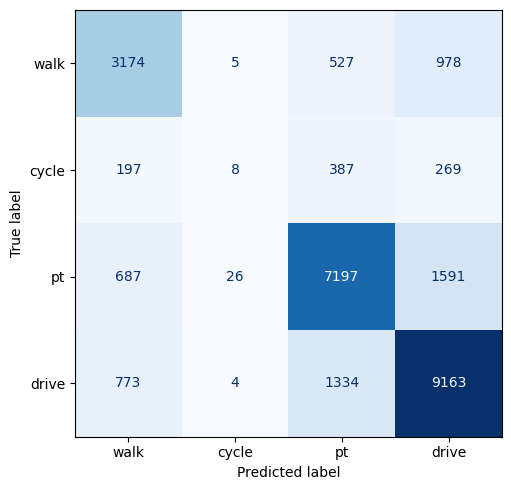

In [85]:
print('Classification report (test):')
print(classification_report(y_test, y_pred_test))

cm = confusion_matrix(y_test, y_pred_test, labels=[0,1,2,3])
fig, ax = plt.subplots(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['walk','cycle','pt','drive'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.tight_layout()
cm_path = ARTIFACTS / 'xgb_confusion_matrix_tuned.png'
plt.savefig(cm_path, dpi=150)
cm_path


## 8. Guardar modelo, scaler y m?tricas

Persisto el modelo entrenado y el scaler (xgb_lpmc_tuned.joblib y xgb_lpmc_scaler.joblib). Escribo un JSON en xgb_lpmc_metrics.json con las métricas de train, test y CV (medias y desviaciones) más los hiperparámetros y el origen (param_source). Este JSON es lo que puedo enseñar directamente a Jose Angel para justificar resultados y configuración.

In [86]:
model_path = MODELS / 'xgb_lpmc_tuned.joblib'
scaler_path = MODELS / 'xgb_lpmc_scaler.joblib'
joblib.dump({'model': clf, 'feature_names': list(X_train_scaled.columns)}, model_path)
joblib.dump({'scaler': scaler, 'scaled_features': scaled_features}, scaler_path)

metrics_path = ARTIFACTS / 'xgb_lpmc_metrics.json'
metrics_payload = {
    'train': {'accuracy': float(acc_train), 'gmpca': float(gmpca_train)},
    'test': {'accuracy': float(acc_test), 'gmpca': float(gmpca_test)},
    'cv': {
        'accuracy_mean': float(np.mean(acc_cv)) if RUN_CV else None,
        'accuracy_std': float(np.std(acc_cv)) if RUN_CV else None,
        'gmpca_mean': float(np.mean(gmpca_cv)) if RUN_CV else None,
        'gmpca_std': float(np.std(gmpca_cv)) if RUN_CV else None,
    },
    'model_params': model_params,
    'param_source': PARAM_SOURCE,
}
metrics_path.write_text(json.dumps(metrics_payload, indent=2))

print('Modelo guardado en', model_path)
print('Scaler guardado en', scaler_path)
print('Metricas guardadas en', metrics_path)


Modelo guardado en f:\TFM\lpmc\models\xgb_lpmc_tuned.joblib
Scaler guardado en f:\TFM\lpmc\models\xgb_lpmc_scaler.joblib
Metricas guardadas en f:\TFM\lpmc\artifacts\xgb_lpmc_metrics.json


In [87]:
metrics = json.loads(Path("artifacts/xgb_lpmc_metrics.json").read_text())
# Tabla sencilla con train/test/CV
rows = [
    ("train", metrics["train"]["accuracy"], metrics["train"]["gmpca"]),
    ("test", metrics["test"]["accuracy"], metrics["test"]["gmpca"]),
    ("cv (media)", metrics["cv"]["accuracy_mean"], metrics["cv"]["gmpca_mean"]),
]
df = pd.DataFrame(rows, columns=["split", "accuracy", "gmpca"])
display(df.style.format({"accuracy": "{:.4f}", "gmpca": "{:.4f}"}))
print("param_source:", metrics.get("param_source"))


,split,accuracy,gmpca
0,train,0.8009,0.5971
1,test,0.7425,0.5101
2,cv (media),0.7552,0.5242


param_source: custom
